# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 61.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 93.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 94.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 89.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [librosa]5/16 [librosa]earn]
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 81.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import sys
import json
import glob

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from scipy.ndimage import gaussian_filter
from tqdm import tqdm


import torch
import torchaudio
from torch.utils.data import random_split, DataLoader


from model.VRNN import VRNN, VRNN_Student
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import *
from experiments.produce_results import mel_to_audio_playable, prep_for_plot

# I- Data

The dataset we used is a subset of the VCTK corpus, available here: https://www.kaggle.com/datasets/pratt3000/vctk-corpus. 

This dataset consists of audio recordings in .wav format from English speakers. We used slightly fewer than 3,000 samples from this dataset to train our models. We converted the data from .wav files into Mel-spectrograms, which is a standard representation for audio machine learning. We also normalized it. These transformations were performed in the notebook 'data transformation from wav to mel.ipynb', located in the 'data' folder.

In [11]:
!git checkout main

M	experiments/.ipynb_checkpoints/VRNN_project_notebook_colab-checkpoint.ipynb
M	experiments/VRNN_project_notebook_colab.ipynb
M	experiments/checkpoints/best.pt
M	experiments/checkpoints/history.json
M	experiments/checkpoints/last.pt
M	model/.ipynb_checkpoints/VRNN-checkpoint.py
M	model/VRNN.py
M	model/__pycache__/VRNN.cpython-313.pyc
Already on 'main'
Your branch is up to date with 'origin/main'.


First we split our dataset in train, validation and test sets.

In [5]:
#liens pour le serveur sspcloud - à changer pour colab: 
data_dirs = [
"/home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_0",
"/home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_1",
"/home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_2"
]

#pour colab 
# data_dirs = [
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_0",
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_1",
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_2"
# ]

# Initialize AudioDataset for each part and concatenate them
full_dataset = torch.utils.data.ConcatDataset([
    AudioDataset(data_dir) for data_dir in data_dirs
])


all_mels = []
for i in range(len(full_dataset)):
    all_mels.append(full_dataset[i])

all_mels_tensor = torch.cat(all_mels, dim=0)

mean_full = all_mels_tensor.mean()
std_full = all_mels_tensor.std()
print("Beware, data is already normalized!!! -> mean and variance are", mean_full,std_full)

Beware, data is already normalized!!! -> mean and variance are tensor(0.1526) tensor(0.9705)


In [6]:
N = len(full_dataset)
train_len = int(0.8 * N)
val_len = int(0.1 * N)
test_len = N - train_len - val_len

print(f"Dataset split: Train {train_len}, Validation {val_len}, Test {test_len} samples.")

g = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=g
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)



Dataset split: Train 2337, Validation 292, Test 293 samples.


Type du batch: <class 'torch.Tensor'>
Shape du batch: torch.Size([200, 32, 80])
Shape séquence 0 : torch.Size([200, 80])
tensor([[ 0.2990,  0.3212, -0.1305,  ..., -0.7122, -0.7750, -0.7808],
        [-1.2087,  0.0524, -0.3052,  ..., -0.7816, -0.9405, -0.9765],
        [-0.6014, -0.9988, -0.8335,  ..., -0.7576, -0.8851, -0.9598],
        ...,
        [-0.3617, -0.2852, -0.8191,  ..., -0.9009, -1.0040, -0.8446],
        [-1.2158,  0.2173,  0.2600,  ..., -0.9354, -1.0364, -0.9511],
        [-0.9288,  0.3951,  0.4309,  ..., -0.8703, -1.0468, -0.8159]])


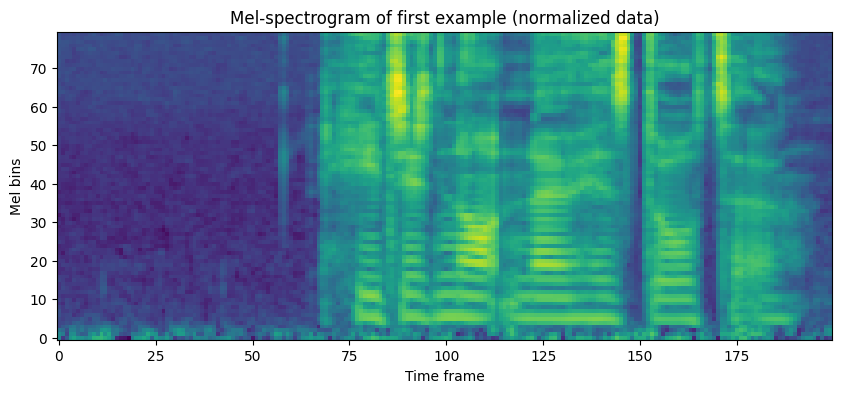

In [7]:
# Récupère le premier batch
batch = next(iter(train_loader))
print("Type du batch:", type(batch))
print("Shape du batch:", batch.shape)

x0 = batch[:, 0, :]   # shape = (seq_len, mel_dim)
print("Shape séquence 0 :", x0.shape)
print(x0)

plt.figure(figsize=(10,4))
plt.imshow(x0.T, aspect="auto", origin="lower")
# plt.colorbar()
plt.title("Mel-spectrogram of first example (normalized data)")
plt.xlabel("Time frame")
plt.ylabel("Mel bins")
plt.show()

# II- Training models

## A) VRNN with gaussian prior

First we will try to train a VRNN model with gaussian prior. We'll play with the various parameters of the training functions that we defined in the train.py file to get the best loss possible.

cuda


Epoch 1/50 Training: 100%|██████████| 74/74 [00:28<00:00,  2.64it/s]


[1/50] Train: -0.724 | Val: -20.837 | β=0.000
 → Saved BEST model


Epoch 2/50 Training: 100%|██████████| 74/74 [00:32<00:00,  2.29it/s]


[2/50] Train: -21.779 | Val: -20.447 | β=0.100


...

[11/50] Train: -42.946 | Val: -41.976 | β=1.000


Epoch 12/50 Training: 100%|██████████| 74/74 [00:31<00:00,  2.34it/s]


[12/50] Train: -43.420 | Val: -42.291 | β=1.000


Epoch 13/50 Training: 100%|██████████| 74/74 [00:30<00:00,  2.40it/s]


[13/50] Train: -43.099 | Val: -39.951 | β=1.000
Early stopping triggered.

Training complete.


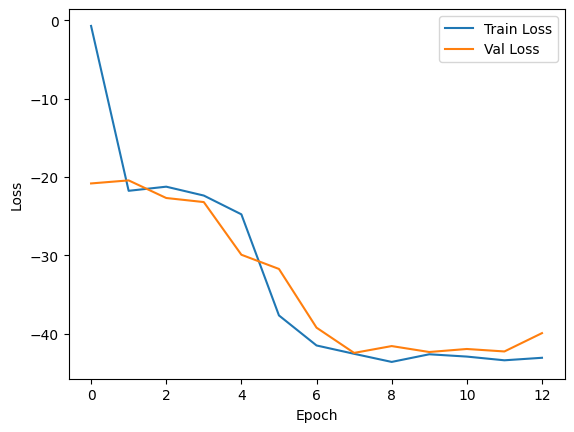

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VRNN().to(device)
print(device)

history = train_model(model=model, train_loader=train_loader, val_loader=val_loader,epochs=50,batch_size=32,lr=1e-3,kl_anneal_epochs=10, patience=5,device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

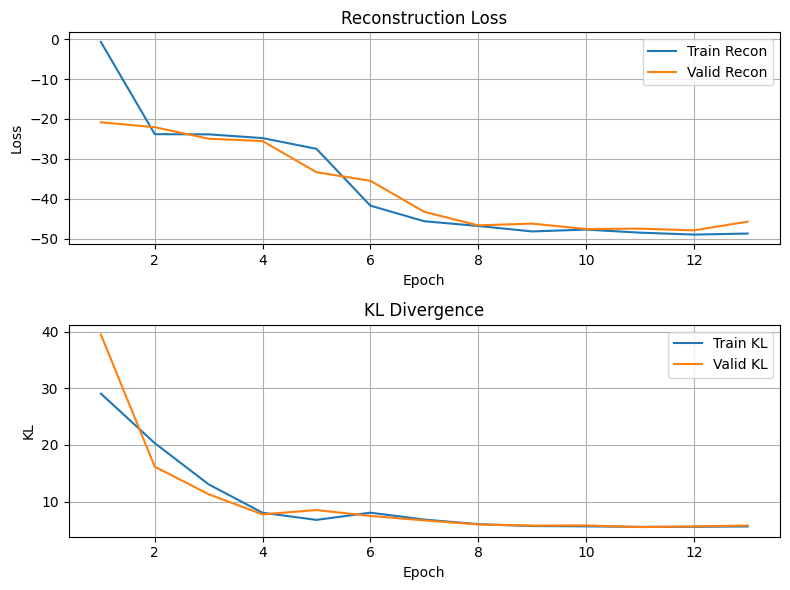

In [10]:

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(8, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


To get better results, we will increase the number of epochs and the KL annealing phase length.

We will also add a scheduler for the learning rate called ReduceLROnPlateau, which reduces the learning rate when the validation curve becomes flat to avoid getting stuck in local minima.

Epoch 1/200 Training: 100%|██████████| 74/74 [00:10<00:00,  7.23it/s]


[1/200] Train: 0.450 | Val: -19.900 | β=0.000 | LR=1.00e-03
 → Saved BEST model


Epoch 2/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.37it/s]


[2/200] Train: -22.123 | Val: -24.206 | β=0.033 | LR=1.00e-03
 → Saved BEST model


Epoch 3/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.52it/s]


...

[198/200] Train: -66.964 | Val: -67.407 | β=1.000 | LR=1.25e-04


Epoch 199/200 Training: 100%|██████████| 74/74 [00:10<00:00,  7.30it/s]


[199/200] Train: -67.071 | Val: -67.390 | β=1.000 | LR=1.25e-04


Epoch 200/200 Training: 100%|██████████| 74/74 [00:09<00:00,  8.02it/s]


[200/200] Train: -67.183 | Val: -67.480 | β=1.000 | LR=1.25e-04
 → Saved BEST model

Training complete.


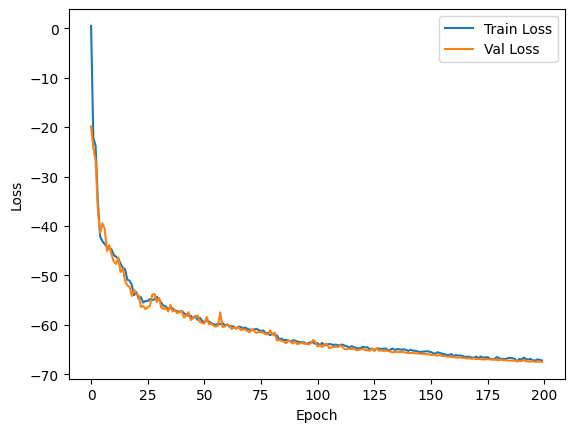

In [33]:
model_2 = VRNN().to(device)

history = train_model_with_scheduler(model=model_2, 
                                     train_loader=train_loader, 
                                     val_loader=val_loader,
                                     epochs=200,
                                     batch_size=32,
                                     lr=1e-3,
                                     kl_anneal_epochs=30, 
                                     patience=15,
                                     device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

After playing a bit with the parameters, here is the best curve that we could get. We can see three phenomena:
- The convergence of the loss is smoother: the loss decreases continuously and smoothly thanks to the scheduler.
- The performance is better with a reconstruction loss going to -80 (vs -50 in the previous case) which results in an improved reconstruction.
- The latent space is better exploited by the model: we can see that after the annealing phase (epochs 30+), the KL slowly increases from 10 to 13. It means that the model improves its reconstruction (as reconstruction loss decreases) while updating the posterior and improving the ability of the latent variable store more complex information. 


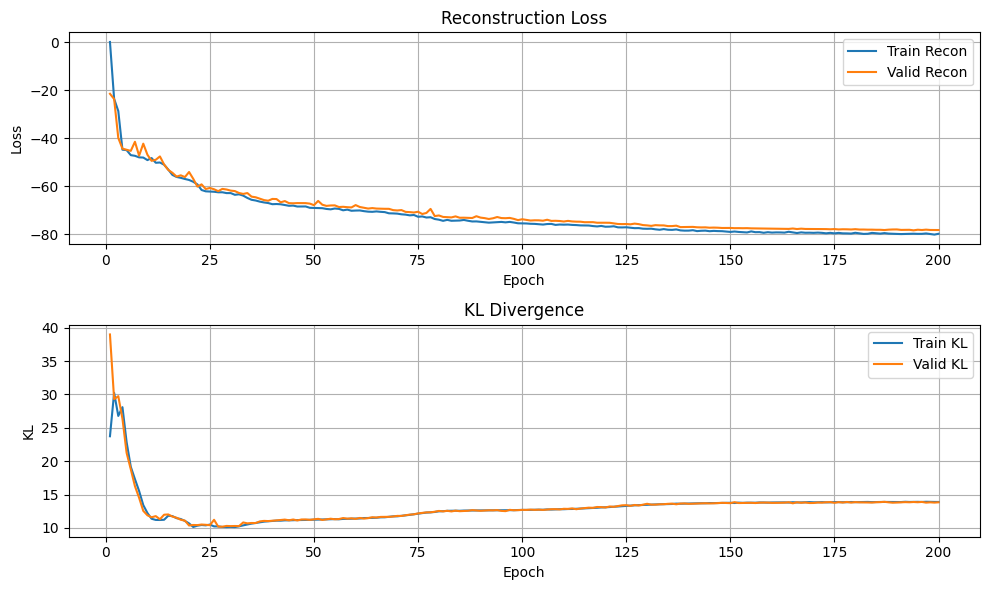

In [18]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## B) VRNN with Student t prior

We can also try replacing the gaussian prior with a Student-T prior with 3 degrees of liberty. This kind of prior is especially suited for data with heavy tail. This could yield better results in our case. 

In this setting, we can't use the reparametrization trick and we have to approximate the KL by Monte Carlo. 

Epoch 1/200 Training: 100%|██████████| 74/74 [00:16<00:00,  4.53it/s]


[1/200] Train: -0.445 | Val: -12.236 | β=0.000 | LR=1.00e-03
 → Saved BEST model


Epoch 2/200 Training: 100%|██████████| 74/74 [00:16<00:00,  4.49it/s]


[2/200] Train: -22.030 | Val: -23.461 | β=0.033 | LR=1.00e-03
 → Saved BEST model


Epoch 3/200 Training: 100%|██████████| 74/74 [00:15<00:00,  4.64it/s]


...

[198/200] Train: -68.071 | Val: -66.111 | β=1.000 | LR=2.50e-04


Epoch 199/200 Training: 100%|██████████| 74/74 [00:16<00:00,  4.59it/s]


[199/200] Train: -67.984 | Val: -66.267 | β=1.000 | LR=2.50e-04


Epoch 200/200 Training: 100%|██████████| 74/74 [00:16<00:00,  4.58it/s]


[200/200] Train: -68.171 | Val: -66.414 | β=1.000 | LR=2.50e-04

Training complete.


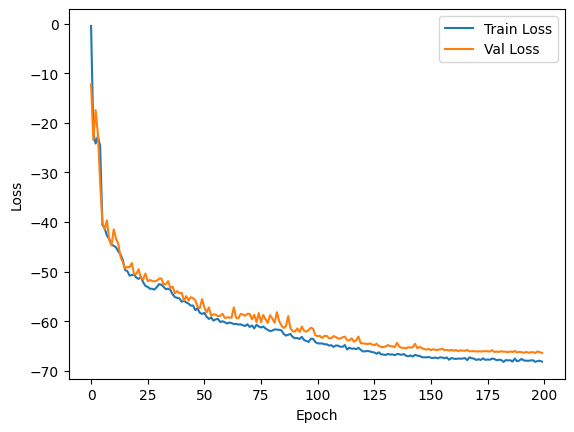

In [20]:
model_4 = VRNN_Student().to(device)

history = train_model_with_scheduler(model=model_4, 
                                     train_loader=train_loader, 
                                     val_loader=val_loader,
                                     epochs=200,
                                     batch_size=32,
                                     lr=1e-3,
                                     kl_anneal_epochs=30, 
                                     patience=30,
                                     device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss - Student t prior")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence - Student t prior")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In terms of training, we get similar results to those of the gaussian prior, although we get a slightly better loss with the gaussian prior. We can now move to analysing the reconstruction of audios.

# III- Reconstruction of audios

## A) VRNN with gaussian prior

First we load the model from the checkpoints.

In [92]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VRNN().to(device)

# 2. Définir le chemin vers le checkpoint
checkpoint_path = "checkpoints/best.pt"  

if not os.path.exists(checkpoint_path):
    print("Attention: 'best.pt' introuvable, essai avec 'last.pt'...")
    checkpoint_path = "checkpoints/last.pt"

# 3. Charger les poids
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    
    epoch_saved = checkpoint["epoch"]
    print(epoch_saved)

    # Mettre en mode évaluation (bloque le Dropout, etc.)
    model.eval()
else:
    print("Aucun checkpoint trouvé.")

155



SAMPLE #0


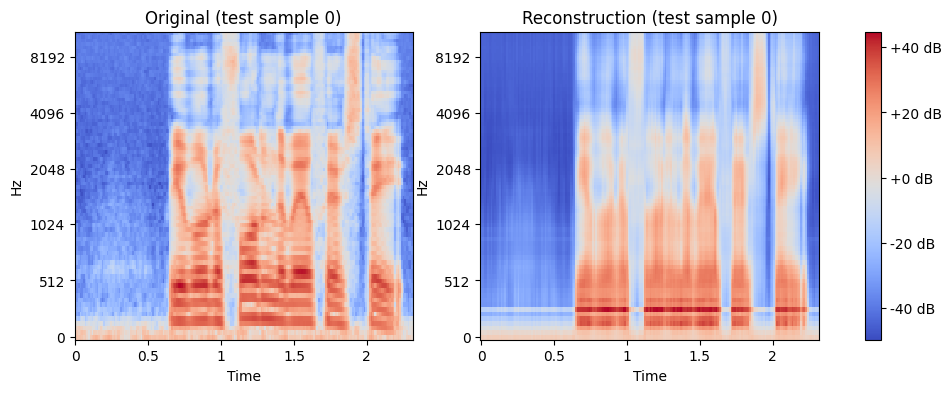


SAMPLE #1


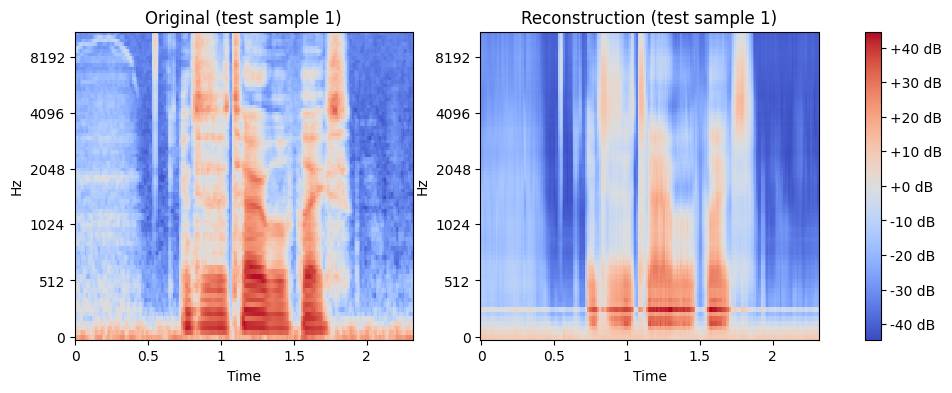


SAMPLE #2


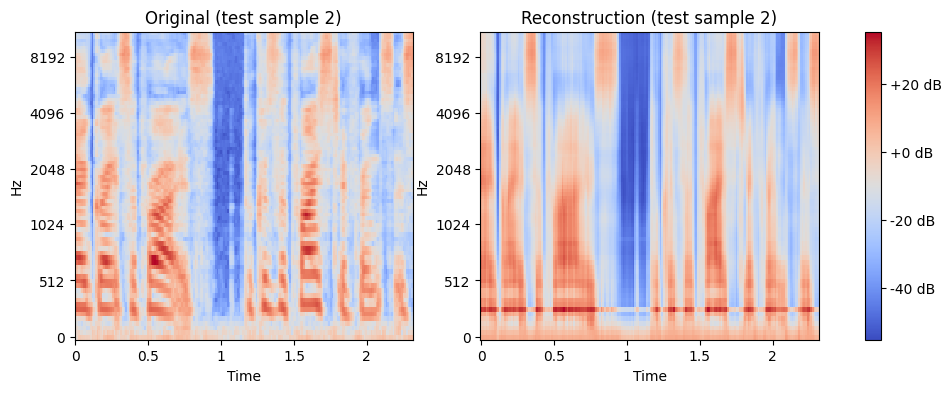


SAMPLE #3


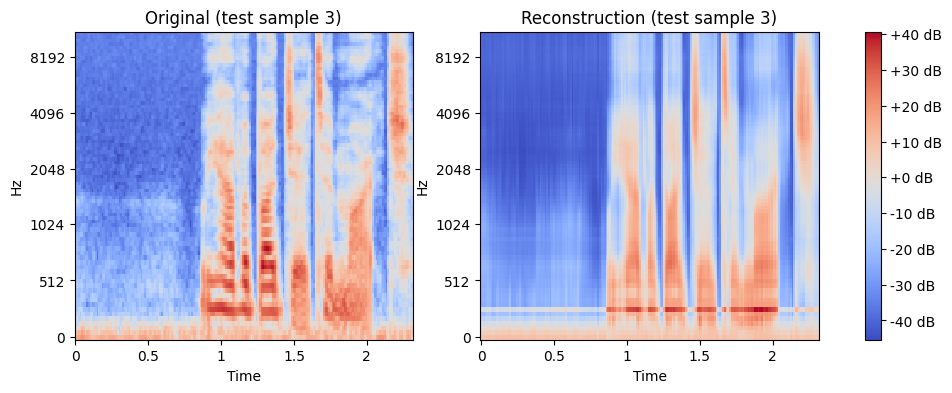


SAMPLE #4


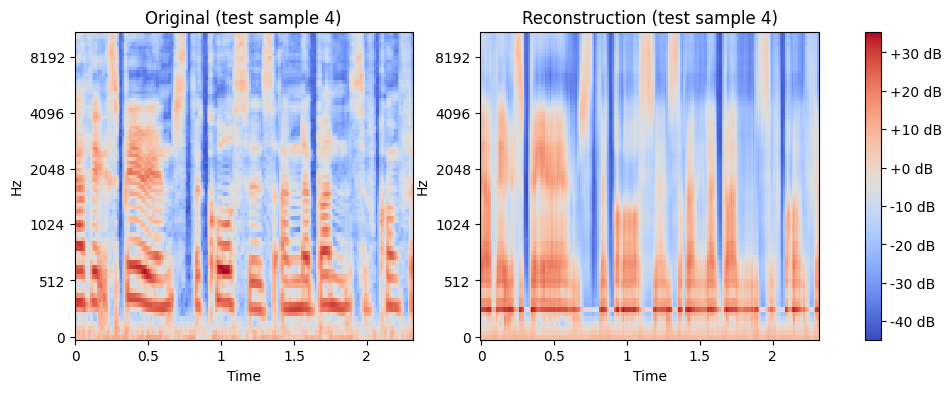

In [94]:

# --- CONFIGURATION ---
STATS_PATH = "mel_stats.pt"
stats = torch.load(STATS_PATH)
mean_val = stats["mean"].to('cpu')
std_val = stats["std"].to('cpu')

# --- BOUCLE DE VISUALISATION ---
for i in range(0, 5):
    print(f"\n" + "="*50)
    print(f"SAMPLE #{i}")
    print("="*50)

    #  Récupération Données
    data_item = test_dataset[i]
    original_mel = data_item[0] if isinstance(data_item, (tuple, list)) else data_item
    
    # Passage Modèle
    input_tensor = original_mel.unsqueeze(1).to(device) # (Seq, Batch, Feat)
    
    with torch.no_grad():
        recon_mel, _, _ = model(input_tensor) 

    recon_mel = recon_mel.squeeze(1).cpu() 
    original_mel = original_mel.cpu()


    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    img_orig = prep_for_plot(original_mel, mean_val, std_val)
    img_recon = prep_for_plot(recon_mel, mean_val, std_val)

    # Affichage Original
    librosa.display.specshow(img_orig, y_axis='mel', x_axis='time', ax=ax[0], sr=22050, hop_length=256)
    ax[0].set_title(f"Original (test sample {i})")
    
    # Affichage Reconstruit
    im = librosa.display.specshow(img_recon, y_axis='mel', x_axis='time', ax=ax[1], sr=22050, hop_length=256)
    ax[1].set_title(f"Reconstruction (test sample {i})")
    
    fig.colorbar(im, ax=ax, format='%+2.0f dB')
    plt.savefig(f"reconstruction vs original - test sample {i}",bbox_inches='tight', dpi=150)
    plt.show() # Affiche les images avant les lecteurs audio
    
    #LECTURE AUDIO
    mel_to_audio_playable(original_mel, mean_val, std_val, f"test sample_{i}_original")
    mel_to_audio_playable(recon_mel, mean_val, std_val, f"test sample_{i}_reconstruction")

Results are overall satisfying, we get similar spectrograms, and when listening to the audio we get very similar results between original and reconstructed audio.

## B) VRNN with Student t prior

In [ ]:

# --- CONFIGURATION ---
STATS_PATH = "mel_stats.pt"
stats = torch.load(STATS_PATH)
mean_val = stats["mean"].to('cpu')
std_val = stats["std"].to('cpu')

# --- BOUCLE DE VISUALISATION ---
for i in range(0, 5):
    print(f"\n" + "="*50)
    print(f"SAMPLE #{i}")
    print("="*50)

    #  Récupération Données
    data_item = test_dataset[i]
    original_mel = data_item[0] if isinstance(data_item, (tuple, list)) else data_item
    
    # Passage Modèle
    input_tensor = original_mel.unsqueeze(1).to(device) # (Seq, Batch, Feat)
    
    with torch.no_grad():
        recon_mel, _, _ = model_4(input_tensor) 

    recon_mel = recon_mel.squeeze(1).cpu() 
    original_mel = original_mel.cpu()


    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    img_orig = prep_for_plot(original_mel, mean_val, std_val)
    img_recon = prep_for_plot(recon_mel, mean_val, std_val)

    # Affichage Original
    librosa.display.specshow(img_orig, y_axis='mel', x_axis='time', ax=ax[0], sr=22050, hop_length=256)
    ax[0].set_title(f"Original (test sample {i})")
    
    # Affichage Reconstruit
    im = librosa.display.specshow(img_recon, y_axis='mel', x_axis='time', ax=ax[1], sr=22050, hop_length=256)
    ax[1].set_title(f"Reconstruction (test sample {i})")
    
    fig.colorbar(im, ax=ax, format='%+2.0f dB')
    plt.savefig(f"reconstruction vs original - test sample {i}",bbox_inches='tight', dpi=150)
    plt.show() # Affiche les images avant les lecteurs audio
    
    #LECTURE AUDIO
    mel_to_audio_playable(original_mel, mean_val, std_val, f"test sample_{i}_original")
    mel_to_audio_playable(recon_mel, mean_val, std_val, f"test sample_{i}_reconstruction")

Results are also very satisfying. We may get slightly better results with the gaussian prior when listening to the audio but it's not obvious.

# IV- Generation 

### A) Cold-start generation

We'll now try to generate data with our trained model. 

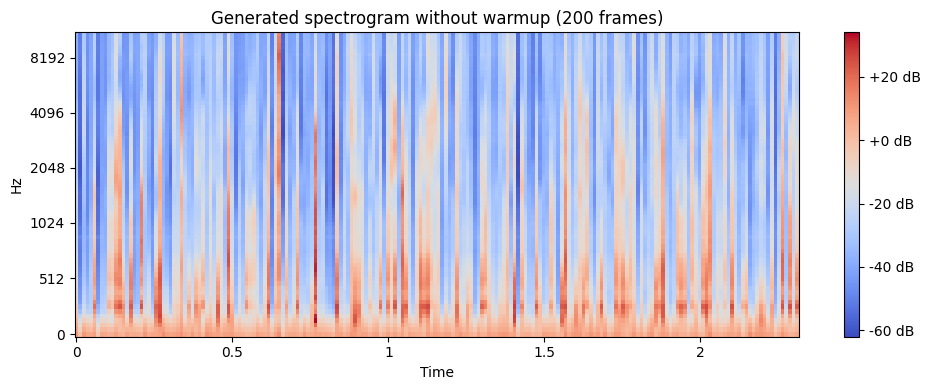

In [11]:

STATS_PATH = "mel_stats.pt"
SEQ_LEN = 200  # Durée de la génération (400 frames ~= 4 à 5 secondes)


stats = torch.load(STATS_PATH)
mean_val = stats["mean"].to('cpu')
std_val = stats["std"].to('cpu')


# 2. GÉNÉRATION (Appel de la méthode generate)
# Le modèle invente une séquence à partir de bruit aléatoire
generated_mel = model.generate(seq_len=SEQ_LEN, device=device)

# 3. TRAITEMENT (En mémoire)
# On passe sur CPU et on dénormalise
generated_mel = generated_mel.cpu()
mel_denorm = generated_mel * (std_val + 1e-6) + mean_val

# Conversion Numpy et Transpose pour Librosa (Freq, Time)
mel_numpy = mel_denorm.numpy()
if mel_numpy.shape[0] > mel_numpy.shape[1]:
    mel_numpy = mel_numpy.T

# 4. VISUALISATION (Plot)
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_numpy, 
    y_axis='mel', 
    x_axis='time', 
    sr=22050, 
    hop_length=256
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Generated spectrogram without warmup ({SEQ_LEN} frames)")
plt.tight_layout()
plt.savefig(f"audio generation without warmup",bbox_inches='tight', dpi=150)
plt.show()

# 5. CONVERSION AUDIO & ÉCOUTE
mel_power = librosa.db_to_power(mel_numpy)
audio_data = librosa.feature.inverse.mel_to_audio(
    mel_power, 
    sr=22050, 
    n_fft=1024, 
    hop_length=256
)

# On passe directement les données brutes au lecteur, sans fichier .wav
ipd.display(ipd.Audio(audio_data, rate=22050))

#### Explanation of this phenomenon:
the spectrogram is random, there is no temporal continuity in the data. This is because we initialized $h$ and $x_t$ to zero in our generation process. Our model has not learned how to start from an empty state so it creates a fully random spectrogram as we don't initialize it with something that allows the model to generate data properly.

We need to do a warmup phase, i.e. we will initialize generation with a true audio to "warm up" the model and get values for $h$ and $x_t$ that make sense and will allow the model to generate something decent.

### B) Generation with priming (warmup phase)

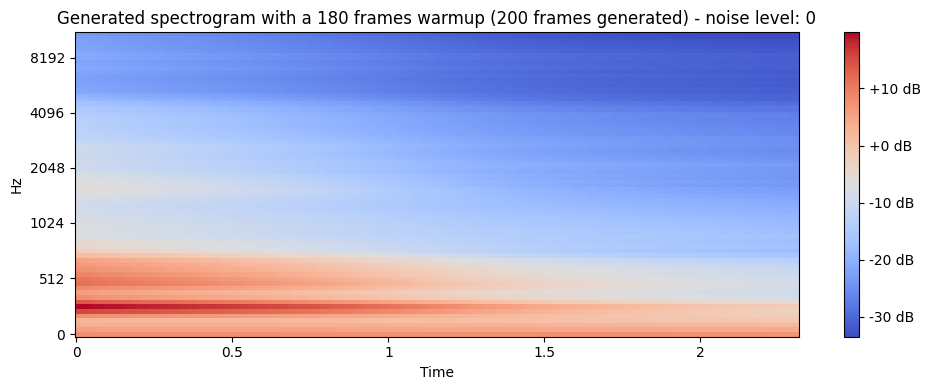

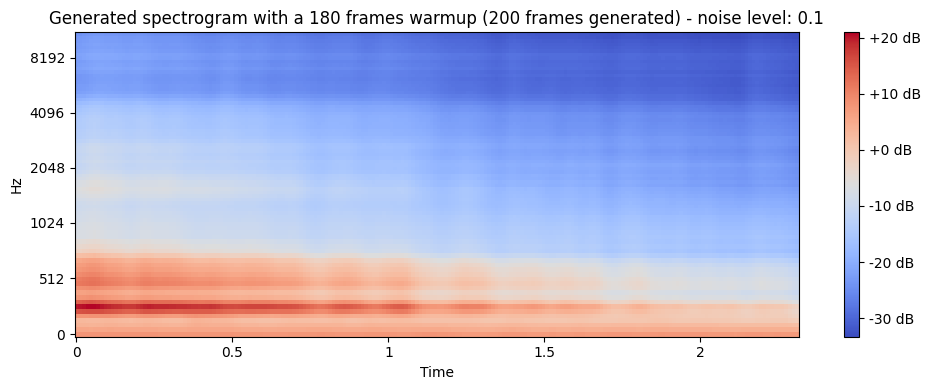

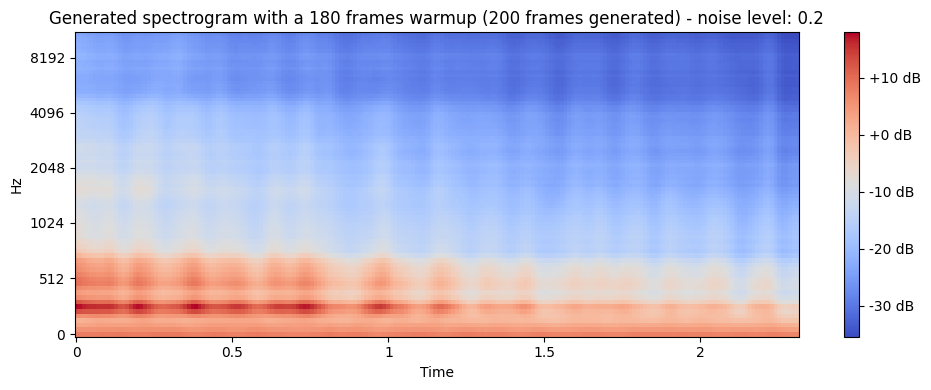

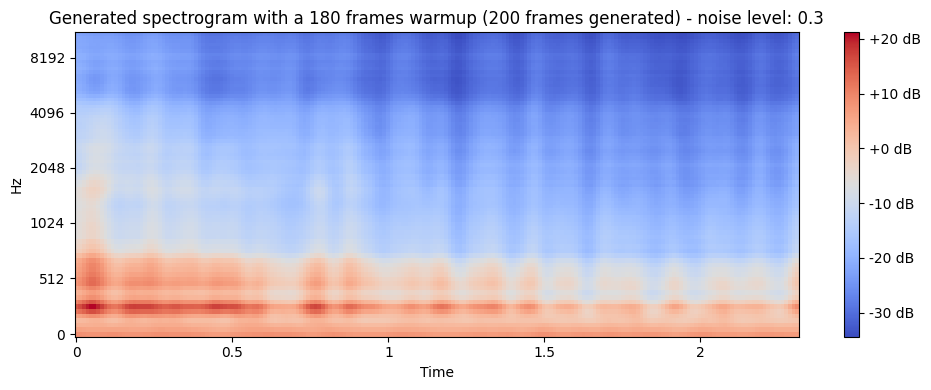

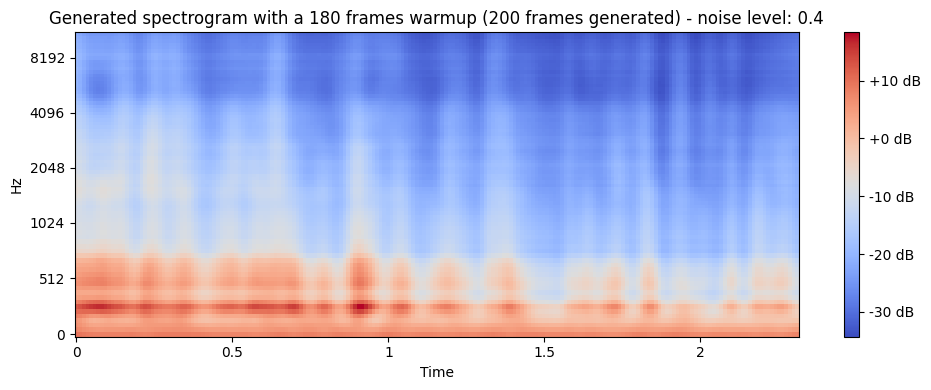

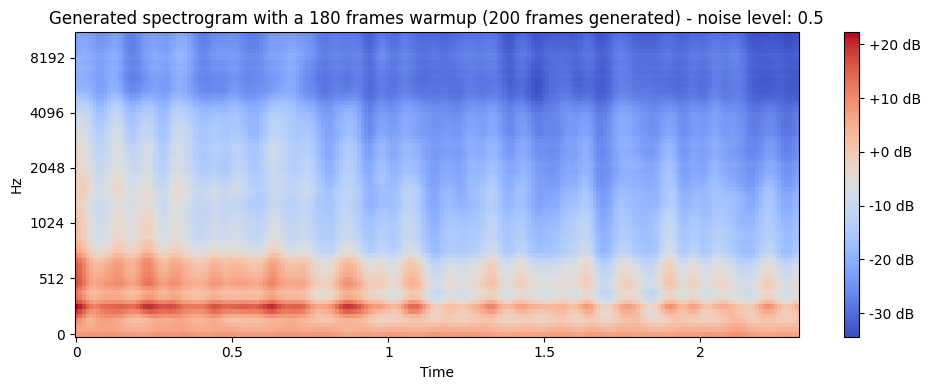

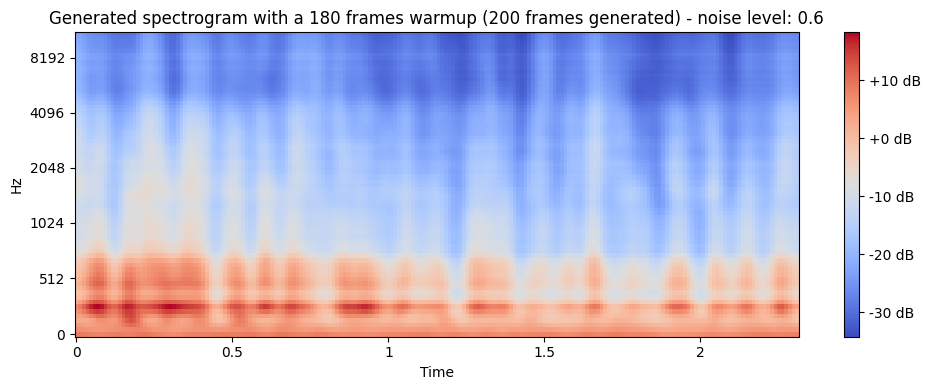

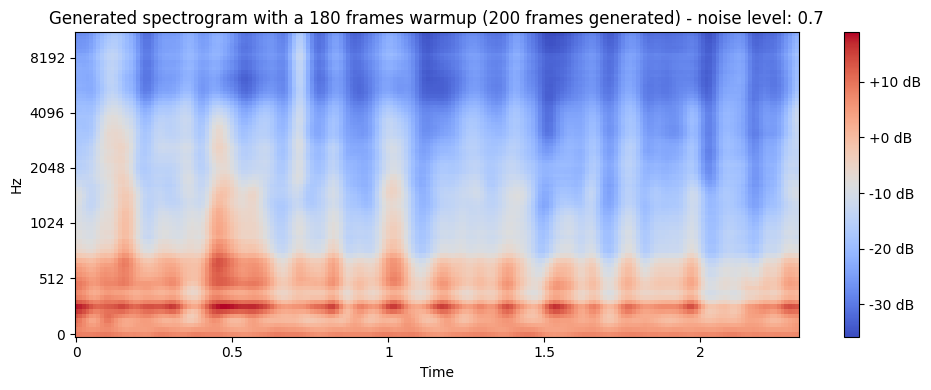

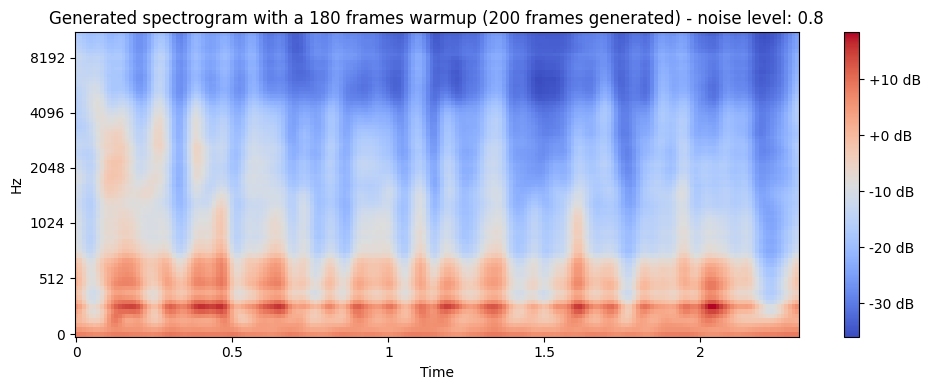

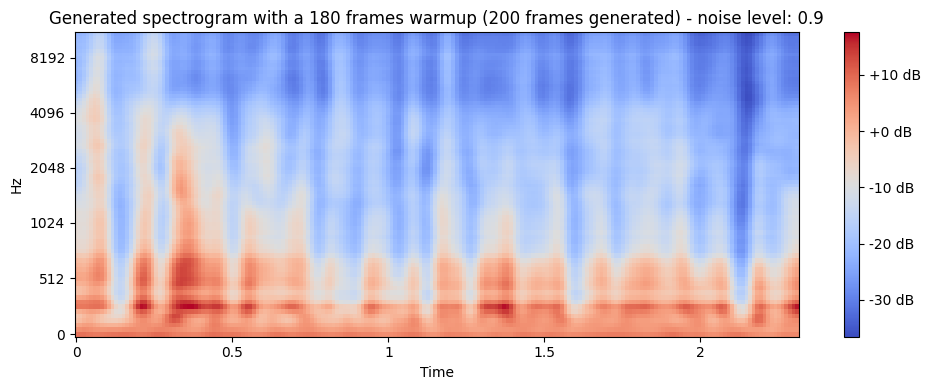

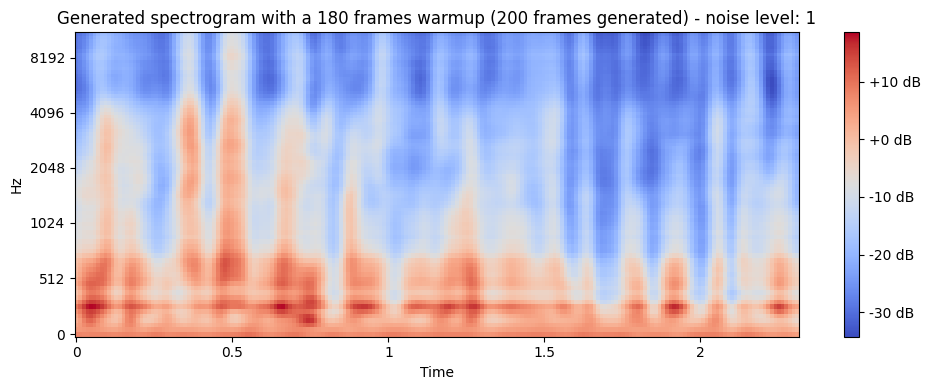

In [91]:
#sample used for warmup
real_sample = train_dataset[2] 
if isinstance(real_sample, tuple): real_sample = real_sample[0]

# we only take the first half of the audio to do the warmup
len_warmup = 180
prime_data = real_sample[:len_warmup].to(device) 

# On génère la suite (200 frames)
SEQ_LEN = 200

for noise_level in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]:
    generated_mel = model.generate_with_priming(seq_len=SEQ_LEN, prime_sequence=prime_data, device=device,noise_level =noise_level)
    mel_denorm = generated_mel.cpu() * (std_val + 1e-6) + mean_val
    
    # Conversion Numpy et Transpose pour Librosa (Freq, Time)
    mel_numpy = mel_denorm.numpy()
    if mel_numpy.shape[0] > mel_numpy.shape[1]:
        mel_numpy = mel_numpy.T

    #essai: rajouter "smoothing gaussien" pour rendre l'audio moins bruité et moins random
    mel_numpy= gaussian_filter(mel_numpy, sigma=(0, 2))
    
    # 4. VISUALISATION (Plot)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mel_numpy, 
        y_axis='mel', 
        x_axis='time', 
        sr=22050, 
        hop_length=256
    )
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Generated spectrogram with a {len_warmup} frames warmup ({SEQ_LEN} frames generated) - noise level: {noise_level}")
    plt.tight_layout()
    plt.savefig(f"audio generation with warmup - noise level: {noise_level}.png",bbox_inches='tight', dpi=150)
    plt.show()
    
    # 5. CONVERSION AUDIO & ÉCOUTE
    mel_power = librosa.db_to_power(mel_numpy)
    audio_data = librosa.feature.inverse.mel_to_audio(
        mel_power, 
        sr=22050, 
        n_fft=1024, 
        hop_length=256
    )
    
    # On passe directement les données brutes au lecteur, sans fichier .wav
    filename = f"audio generation with {len_warmup} frames warmup - {SEQ_LEN} generated - with gaussian smoothing.wav"
    sf.write(filename, audio_data, 22050)
    display(ipd.Audio(filename))

Attempts to improve generation: 
- we added a warmup phase to initialize internal state with values that are known by the model. We tried several samples to initialize, both in the training and test dataset, and we tried several warmup sequence lengths but it did not improve much the generated audio.
- we reduced the variance of $z_t$ to have less noise in the data generated.
- we did post-processing on the audio by adding a gaussian filter to smooth out the noise but it did not improve much either.

Now we will try to retrain a model with the scheduled sampling trick to see if we can get improvements when generating audios.

### C) Retraining a model with scheduled sampling for better generation

We need to introduce another function that trains the model for this.

Epoch 1/200 Training: 100%|██████████| 74/74 [00:12<00:00,  6.10it/s]


[1/200] Train: 1.086 | Val (Recon): -19.202 | Gen (Auto): 155.760 | LR=1.00e-03 | ratio=1.00
 → Saved BEST model (Best Gen Loss: 155.7599)


Epoch 2/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.38it/s]


[2/200] Train: -21.586 | Val (Recon): -23.361 | Gen (Auto): 1000.290 | LR=1.00e-03 | ratio=0.99


Epoch 3/200 Training: 100%|██████████| 74/74 [00:12<00:00,  6.16it/s]


...

[162/200] Train: -14.172 | Val (Recon): -57.960 | Gen (Auto): 32.785 | LR=6.25e-05 | ratio=0.50


Epoch 163/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.58it/s]


[163/200] Train: -14.646 | Val (Recon): -58.008 | Gen (Auto): 33.322 | LR=6.25e-05 | ratio=0.50


Epoch 164/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.31it/s]


[164/200] Train: -15.255 | Val (Recon): -58.038 | Gen (Auto): 32.643 | LR=3.13e-05 | ratio=0.50
Early stopping triggered after 18 epochs without improvement on Generation.

Training complete.


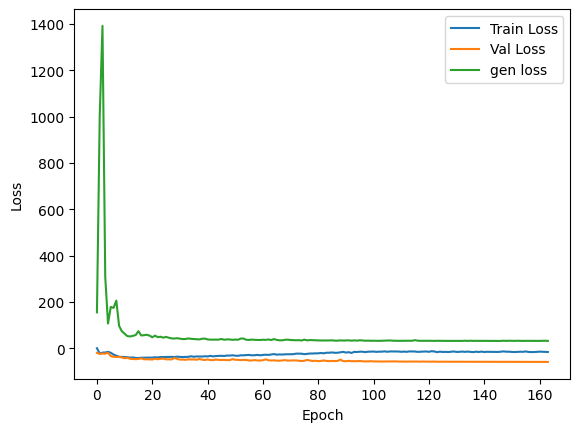

In [118]:
model_3 = VRNN().to(device)

history = train_model_with_scheduler_and_scheduledsampling(model=model_3, 
                                     train_loader=train_loader, 
                                     val_loader=val_loader,
                                     epochs=200,
                                     batch_size=32,
                                     lr=1e-3,
                                     kl_anneal_epochs=30, 
                                     patience=18,
                                     device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.plot(history['gen'],label = 'gen loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

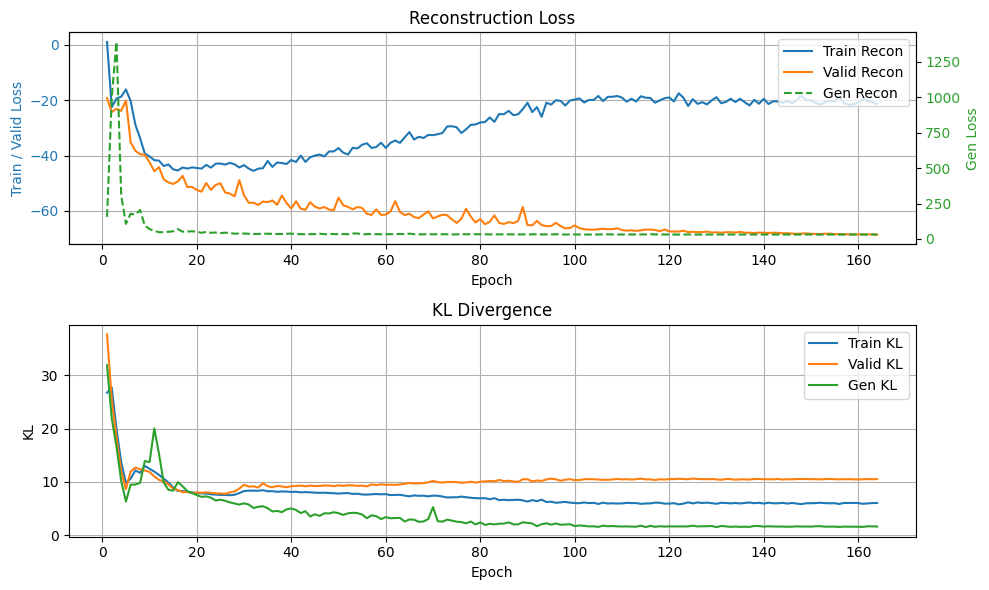

In [131]:
plt.figure(figsize=(10, 6))

ax1 = plt.subplot(2, 1, 1)

color_train = 'tab:blue'
color_val = 'tab:orange'
l1 = ax1.plot(epochs, train_recon, label="Train Recon", color=color_train)
l2 = ax1.plot(epochs, val_recon, label="Valid Recon", color=color_val)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train / Valid Loss", color=color_train)
ax1.tick_params(axis='y', labelcolor=color_train)
ax1.grid(True)

ax2 = ax1.twinx() 
color_gen = 'tab:green'
l3 = ax2.plot(epochs, gen_recon, label="Gen Recon", color=color_gen, linestyle='--')

ax2.set_ylabel("Gen Loss", color=color_gen)
ax2.tick_params(axis='y', labelcolor=color_gen)

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title("Reconstruction Loss")


# ==========================================
# 2ème Plot : KL Divergence (Standard)
# ==========================================
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.plot(epochs, gen_kld, label="Gen KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The loss and KL have a weird aspect. Unfortunately, scheduled sampling does not yield better results in terms of generation as shown by the generated plots below.

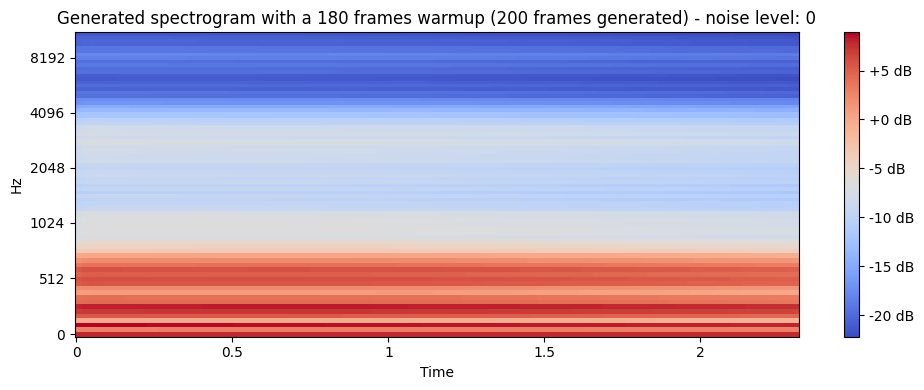

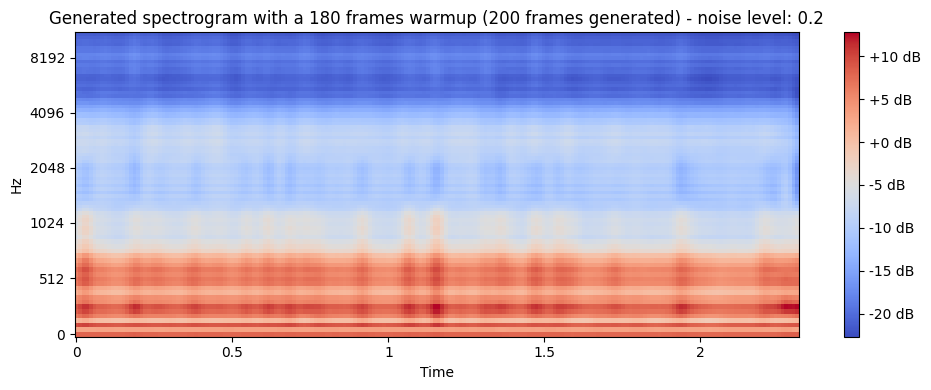

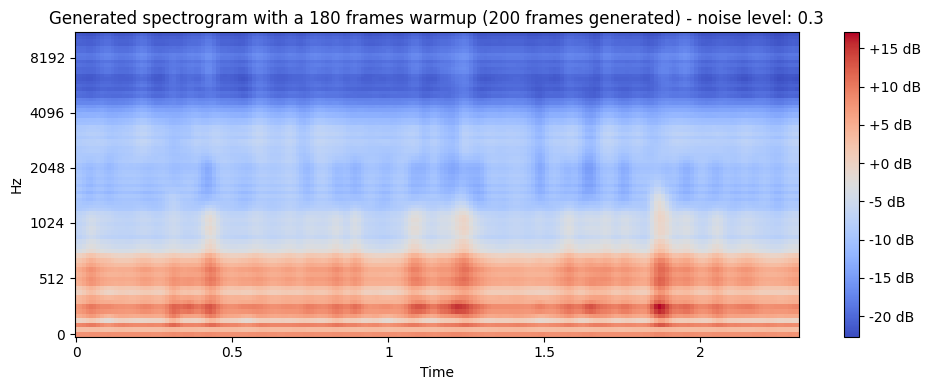

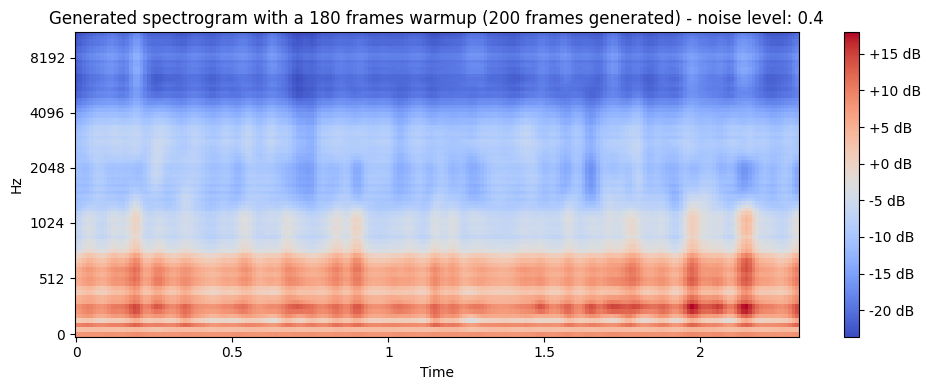

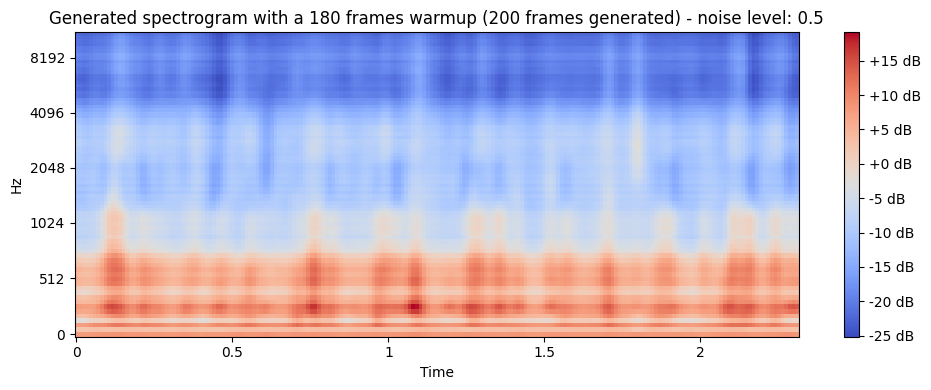

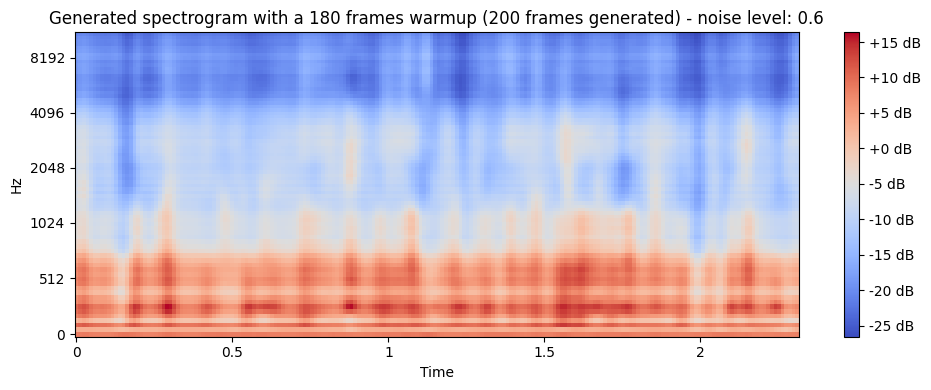

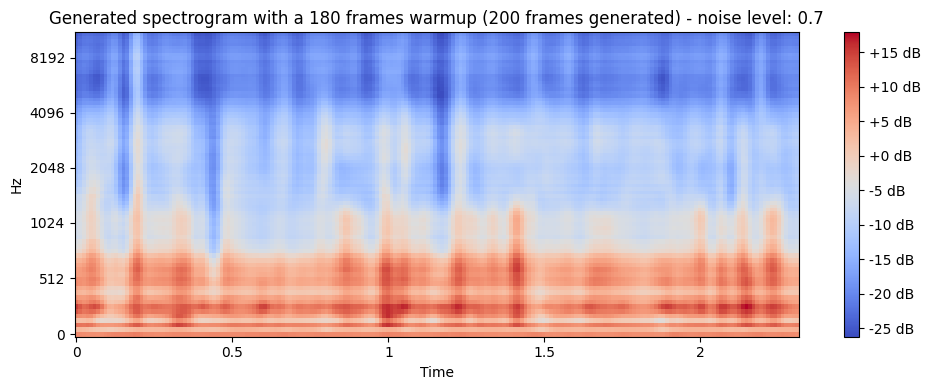

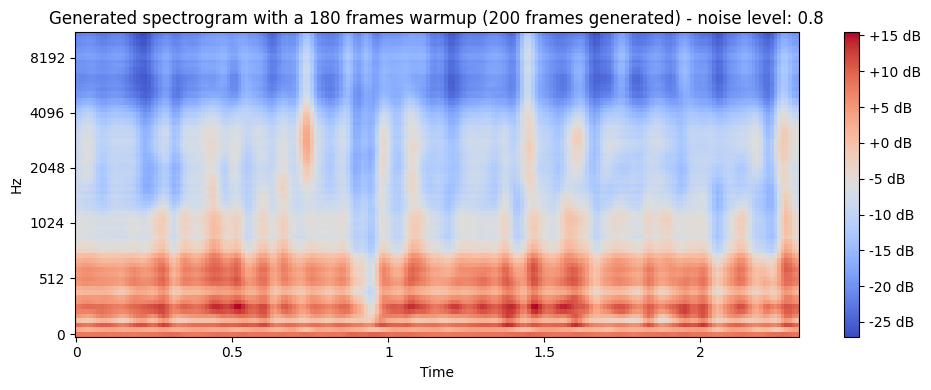

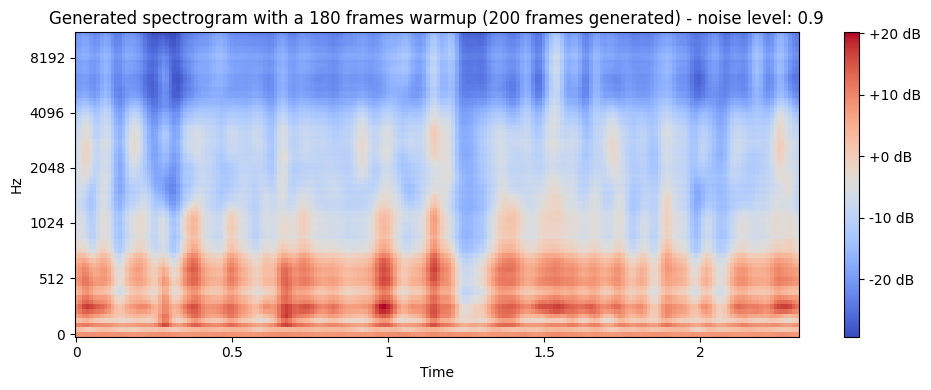

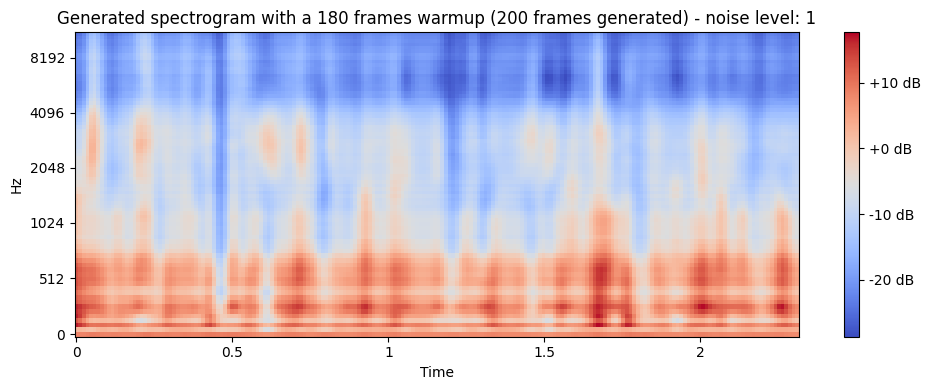

In [126]:
#sample used for warmup
real_sample = train_dataset[2] 
if isinstance(real_sample, tuple): real_sample = real_sample[0]

# we only take the first half of the audio to do the warmup
len_warmup = 180
prime_data = real_sample[:len_warmup].to(device) 

SEQ_LEN = 200

for noise_level in [0,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,]:
    generated_mel = model_3.generate_with_priming(seq_len=SEQ_LEN, prime_sequence=prime_data, device=device,noise_level =noise_level)
    mel_denorm = generated_mel.cpu() * (std_val + 1e-6) + mean_val
    
    mel_numpy = mel_denorm.numpy()
    if mel_numpy.shape[0] > mel_numpy.shape[1]:
        mel_numpy = mel_numpy.T

    mel_numpy= gaussian_filter(mel_numpy, sigma=(0, 1.5))
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mel_numpy, 
        y_axis='mel', 
        x_axis='time', 
        sr=22050, 
        hop_length=256
    )
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Generated spectrogram with a {len_warmup} frames warmup ({SEQ_LEN} frames generated) - noise level: {noise_level}")
    plt.tight_layout()
    plt.savefig(f"[scheduled sampling] audio generation with warmup - noise level: {noise_level}.png",bbox_inches='tight', dpi=150)
    plt.show()
    
    mel_power = librosa.db_to_power(mel_numpy)
    audio_data = librosa.feature.inverse.mel_to_audio(
        mel_power, 
        sr=22050, 
        n_fft=1024, 
        hop_length=256
    )

    filename = f" [scheduled sampling] audio generation with {len_warmup} frames warmup - {SEQ_LEN} generated - with gaussian smoothing.wav"
    sf.write(filename, audio_data, 22050)
    display(ipd.Audio(filename))

Spectrograms are still unstructured, meaning that we don't get much better results with a model trained with scheduled sampling. Maybe our model needs more data (we only used 3000 samples of the VCTK dataset) to get better results. 

# Conclusion

- VRNN and SRNN effectively compress data into a low-dimensional latent space, achieving satisfactory reconstruction even with a small subset of the VCTK dataset.
- However, generation quality remains poor; the RNN struggles with autoregressive prediction, resulting in unstructured spectrograms. 
- Future work should involve training on the full dataset and exploring other  architectures such as RVAE, DSAE, STORN, or generative paradigms like Diffusion Models and GANs. 